In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [23]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [24]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [25]:
df = df.replace('?', pd.NA)

In [26]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),<NA>,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),<NA>,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),<NA>,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),<NA>,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),<NA>,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [27]:
df = df.dropna(subset=['race', 'weight', 'time_in_hospital', 'num_procedures'])

In [44]:
df['weight']

,weight
1102,[75-100)
1132,[0-25)
1136,[75-100)
1190,[75-100)
1204,[50-75)
...,...
101456,[75-100)
101516,[100-125)
101640,[50-75)
101667,[75-100)


In [45]:
df['num_procedures']

,num_procedures
1102,3
1132,5
1136,3
1190,0
1204,5
...,...
101456,4
101516,0
101640,1
101667,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3059 entries, 1102 to 101723
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              3059 non-null   int64 
 1   patient_nbr               3059 non-null   int64 
 2   race                      3059 non-null   object
 3   gender                    3059 non-null   object
 4   age                       3059 non-null   object
 5   weight                    3059 non-null   object
 6   admission_type_id         3059 non-null   int64 
 7   discharge_disposition_id  3059 non-null   int64 
 8   admission_source_id       3059 non-null   int64 
 9   time_in_hospital          3059 non-null   int64 
 10  payer_code                2230 non-null   object
 11  medical_specialty         1569 non-null   object
 12  num_lab_procedures        3059 non-null   int64 
 13  num_procedures            3059 non-null   int64 
 14  num_medications         

In [30]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,3.059000e+03,3.059000e+03,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000,3059.000000
mean,1.573140e+08,7.127354e+07,2.360575,2.711344,6.114743,4.795358,53.171952,1.470415,16.282772,1.105917,0.243544,0.593331,7.999346
std,1.012767e+08,3.102807e+07,1.739707,2.873398,4.921912,2.986447,18.918758,1.766455,7.728520,1.893993,0.773067,1.238169,1.503430
min,8.042082e+06,1.629000e+03,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.468698e+07,5.418710e+07,1.000000,1.000000,1.000000,3.000000,41.000000,0.000000,11.000000,0.000000,0.000000,0.000000,7.000000
50%,1.294328e+08,7.663415e+07,2.000000,1.000000,7.000000,4.000000,55.000000,1.000000,15.000000,0.000000,0.000000,0.000000,9.000000
75%,2.142911e+08,9.589463e+07,3.000000,3.000000,7.000000,6.000000,68.000000,2.000000,20.000000,2.000000,0.000000,1.000000,9.000000
max,4.436958e+08,1.842748e+08,6.000000,18.000000,17.000000,14.000000,105.000000,6.000000,65.000000,21.000000,13.000000,21.000000,9.000000


In [31]:
df.groupby('race')['time_in_hospital'].mean()

,time_in_hospital
race,
AfricanAmerican,4.805310
Asian,3.666667
Caucasian,4.809082
Other,3.766667


In [32]:
race_hosptime = df.groupby('race')['time_in_hospital'].mean()

In [33]:
weight_hosptime = df.groupby('weight')['time_in_hospital'].mean()

In [48]:
weight_procedures = df.groupby('weight')['num_procedures'].mean()

In [37]:
df.groupby(['race', 'weight'])['time_in_hospital'].count()

race             weight   
AfricanAmerican  >200            1
                 [0-25)          6
                 [100-125)      27
                 [125-150)       5
                 [150-175)       1
                 [175-200)       1
                 [25-50)         4
                 [50-75)        25
                 [75-100)       43
Asian            [50-75)         8
                 [75-100)        1
Caucasian        >200            2
                 [0-25)         40
                 [100-125)     567
                 [125-150)     129
                 [150-175)      33
                 [175-200)       9
                 [25-50)        88
                 [50-75)       816
                 [75-100)     1223
Other            [0-25)          1
                 [100-125)       2
                 [125-150)       2
                 [25-50)         1
                 [50-75)        12
                 [75-100)       12
Name: time_in_hospital, dtype: int64

In [69]:
df['race'].value_counts()

,count
race,
Caucasian,2907
AfricanAmerican,113
Other,30
Asian,9


<Axes: title={'center': 'hospital stay time by race'}, xlabel='race'>

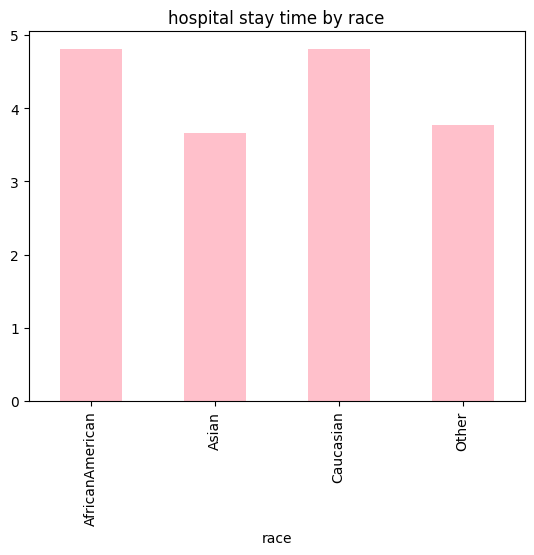

In [55]:
race_hosptime.plot(kind='bar',color=['pink'], title='hospital stay time by race')

In [63]:
import seaborn as sns

<Axes: xlabel='race', ylabel='time_in_hospital'>

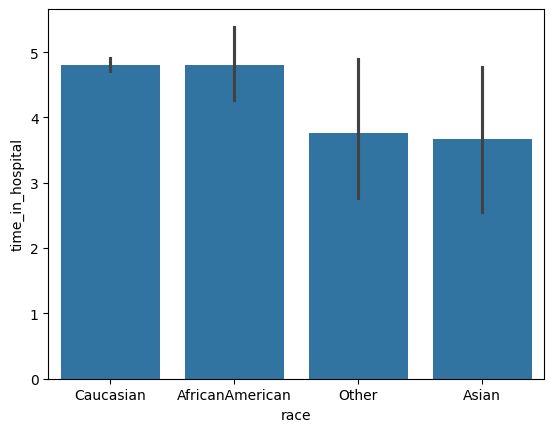

In [64]:
sns.barplot(x='race', y='time_in_hospital', data=df)

<Axes: title={'center': 'hospital stay time by weight'}, xlabel='weight'>

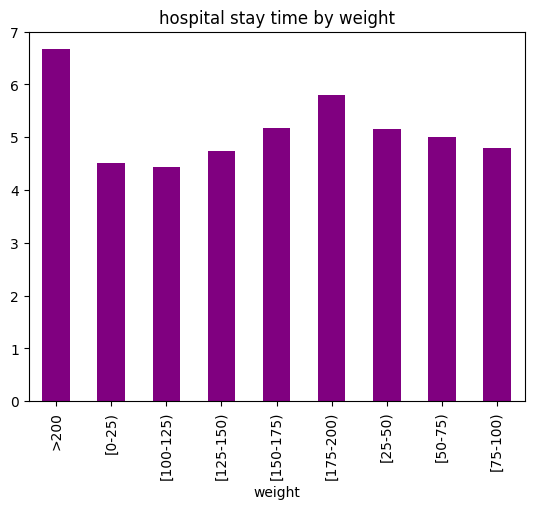

In [57]:
weight_hosptime.plot(kind='bar', color=['purple'], title='hospital stay time by weight')

<Axes: xlabel='weight', ylabel='time_in_hospital'>

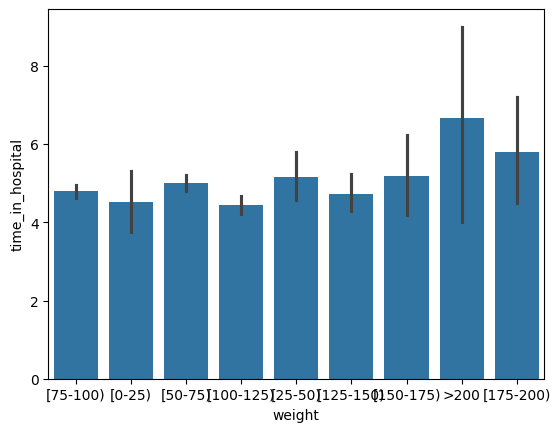

In [72]:
sns.barplot(data=df, x='weight', y='time_in_hospital')

<Axes: title={'center': '# of procedures perfomed by weight'}, xlabel='weight'>

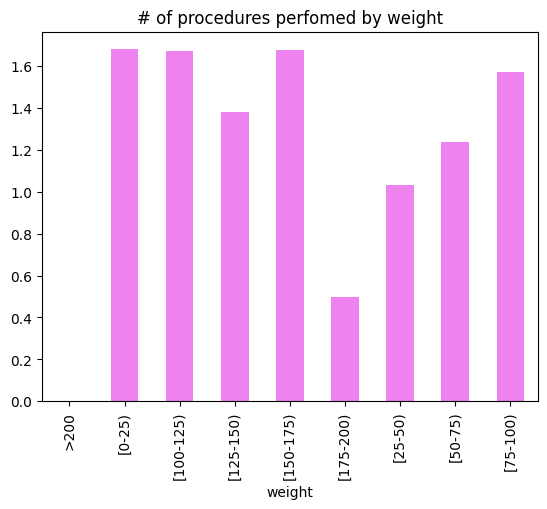

In [58]:
weight_procedures.plot(kind='bar',color=['violet'], title='# of procedures perfomed by weight')

<Axes: xlabel='weight', ylabel='num_procedures'>

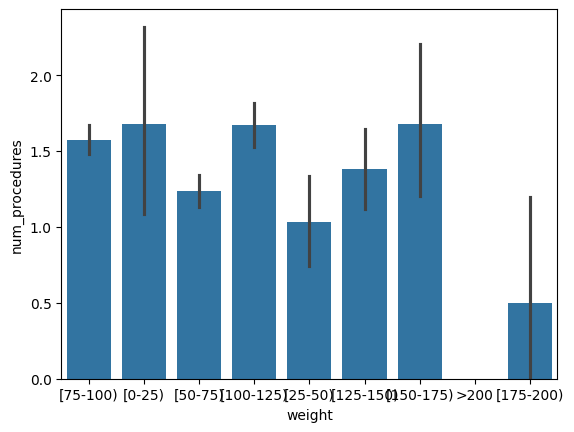

In [66]:
sns.barplot(data=df, x='weight', y='num_procedures')

In [ ]:
#According to the data it seemed that race had little impact on the length of hospital stays. The numbers were slightly lower for Asian and "Other race" identified patiens. However, I dont think the data based on race is reliable as Caucasion makes up more than 90% of the data while we have smaller subsets of data for the other races. However, weight groups demonstrate a connection to longer hospital stays. The higher weight ranges generally the longer hospital stays and more procedures.

According to the data it seemed that race had little impact on the length of hospital stays. The numbers were slightly lower for Asian and "Other race" identified patiens. However, I dont think the data based on race is reliable as Caucasion makes up more than 90% of the data while we have smaller subsets of data for the other races. However, weight groups demonstrate a connection to longer hospital stays. The higher weight ranges generally the longer hospital stays and more procedures.